<a href="https://colab.research.google.com/github/TAUforPython/NeuralODE/blob/main/NeuralODE_simple_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simpla Example Neural ODE

In [1]:
!pip install heyoka -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.0/104.0 MB 7.4 MB/s eta 0:00:00


### Neural Ordinary Differential Equations (Neural ODEs)

Neural Ordinary Differential Equations (Neural ODEs) represent a paradigm shift in deep learning architectures, moving away from discrete layers to continuous-depth models. Instead of stacking layers sequentially, a Neural ODE defines the transformation of a hidden state over time using an ordinary differential equation (ODE) solver.

#### 1. The Core Idea: Continuous Transformations

Traditional neural networks, like ResNets, can be viewed as approximations of an Euler-discretized ODE:

$h_{t+1} = h_t + f(h_t, \theta_t)$

where $h_t$ is the hidden state at layer $t$, and $f$ is a function parameterized by $\theta_t$ (the weights of that layer).

Neural ODEs take this concept to its continuous limit. Instead of a sequence of discrete updates, the hidden state $h(t)$ is defined by a continuous dynamics function:

$\frac{dh(t)}{dt} = f(h(t), t, \theta)$

Here, $f$ is a neural network that describes the instantaneous rate of change of the hidden state, and $\theta$ represents the parameters of this network.

#### 2. How it Works: ODE Solvers

To compute the output of a Neural ODE, we need to solve this initial value problem. Given an initial hidden state $h(t_0)$ (often the input to the model), we integrate the ODE from $t_0$ to $t_1$ to get the final hidden state $h(t_1)$. This integration is performed by off-the-shelf ODE solvers (e.g., Runge-Kutta methods, Adams methods).

$h(t_1) = h(t_0) + \int_{t_0}^{t_1} f(h(t), t, \theta) dt$

Crucially, the ODE solver handles the 'layers' implicitly. The number of 'layers' is not fixed; it's determined by the solver's adaptive step size control, which can take more steps when the dynamics are complex and fewer when they are simple.

#### 3. Training Neural ODEs: Adjoint Sensitivity Method

One of the most significant challenges in continuous models is calculating gradients for backpropagation. Since there are no explicit layers to backpropagate through, standard automatic differentiation techniques are inefficient or impossible.

Neural ODEs address this using the **adjoint sensitivity method**. This method calculates the gradients of the loss function with respect to the network parameters $\theta$ by solving another (augmented) ODE backwards in time. This involves defining an **adjoint state** $a(t) = \frac{\partial L}{\partial h(t)}$, which measures how much the loss $L$ would change if the hidden state $h(t)$ were perturbed. The dynamics of the adjoint state are given by:

$\frac{da(t)}{dt} = -a(t)^T \frac{\partial f}{\partial h(t)}$

The gradient with respect to parameters $\theta$ can then be calculated by integrating another term:

$\frac{dL}{d\theta} = -\int_{t_0}^{t_1} a(t)^T \frac{\partial f}{\partial \theta} dt$

This method has several advantages:
*   **Memory Efficiency:** It does not need to store all intermediate hidden states, only the current hidden state and the adjoint state. This makes it particularly memory-efficient for very deep (long integration time) models.
*   **Continuous Gradients:** It provides accurate gradients for continuous-time models.

#### 4. Advantages of Neural ODEs

*   **Memory Efficiency:** As noted, they don't require storing intermediate activations for backpropagation.
*   **Adaptive Computation:** ODE solvers can adapt their step size, allowing the model to use more computational resources where the dynamics are complex and less where they are simple. This can lead to more efficient learning.
*   **Modeling Irregularly Sampled Data:** Naturally handle data where observations are not uniformly spaced in time, as the ODE can be integrated between arbitrary time points.
*   **Interpretability:** The continuous nature can offer new avenues for understanding the dynamics learned by the network.

#### 5. Disadvantages

*   **Computational Cost:** Solving ODEs, especially during training with the adjoint method, can be computationally more expensive than forward-pass and backpropagation in discrete networks, particularly if high accuracy is required from the ODE solver.
*   **Sensitivity to Solvers:** The choice of ODE solver and its parameters (e.g., tolerance) can significantly impact training stability and performance.

Neural ODEs open up exciting possibilities for modeling dynamic systems, time series, and other continuous phenomena, providing a differentiable and memory-efficient way to learn complex transformations over continuous time.

Libraries imported successfully.

--- Step 1: Generating Ground Truth Data ---
Dynamics defined symbolically:
  dx/dt = ((-0.10000000000000001 * ((x * x) * x)) - (2.0000000000000000 * ((y * y) * y)))
  dy/dt = ((2.0000000000000000 * ((x * x) * x)) - (0.10000000000000001 * ((y * y) * y)))
Ground truth data generated with 1000 points.


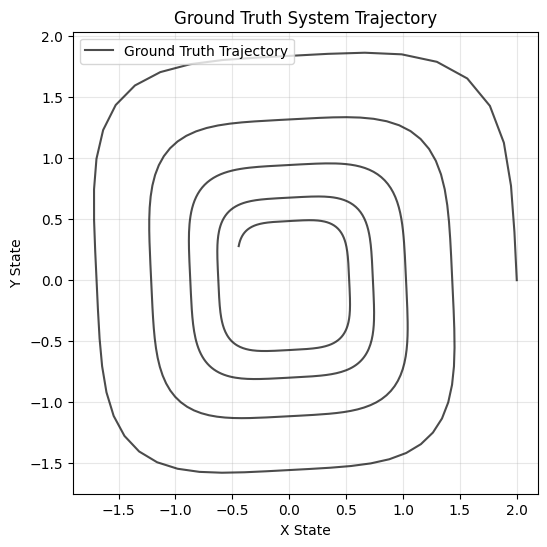


--- Step 2: Instantiating the Neural ODE Model ---
SIMD Batch Size: 4
Neural ODE model instantiated with variational equations for training.

--- Step 3: Setting up Mini-Batching ---
Batch sizes set: ICs=20, Time Steps=10

--- Step 4: Training the Neural ODE ---
Starting training for 1000 epochs...
Epoch [200/1000], Loss: 0.069110
Epoch [400/1000], Loss: 0.003441
Epoch [600/1000], Loss: 0.023450
Epoch [800/1000], Loss: 0.020575
Epoch [1000/1000], Loss: 0.000396

Training completed in 7.92 seconds.


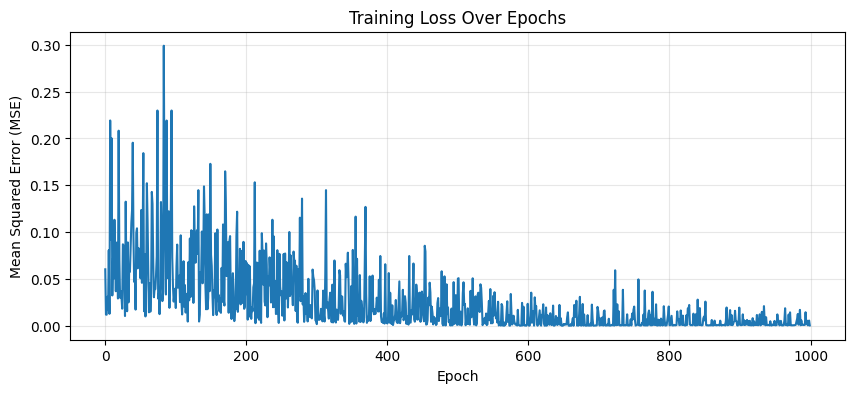


--- Step 5: Visualizing Final Prediction ---
Predicting the full trajectory using the trained Neural ODE...


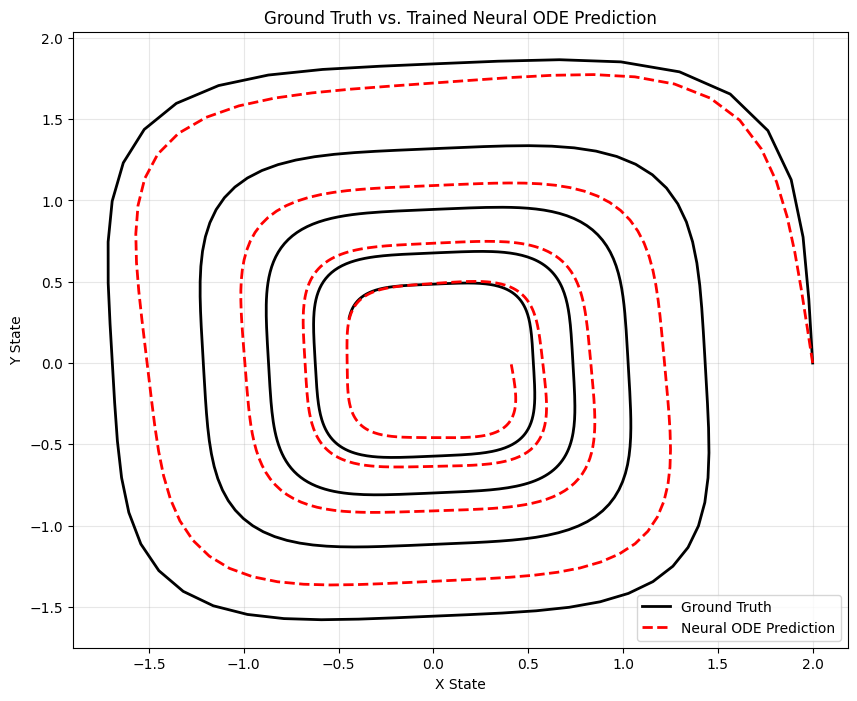


Demonstration Complete!
The Neural ODE has learned to approximate the dynamics of the original system.
The red dashed line (prediction) closely follows the black solid line (ground truth).


In [2]:
# @title Import Libraries
import numpy as np
import time
from itertools import batched
from copy import deepcopy
import heyoka as hy
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

# --- 1. GENERATE GROUND TRUTH DATA ---
print("\n--- Step 1: Generating Ground Truth Data ---")

# Symbolic variables for the ODE state
x, y = hy.make_vars("x", "y")

# Define the true dynamics: dx/dt = f_x(x,y), dy/dt = f_y(x,y)
# Using the matrix A from the tutorial for the specific spiral dynamics
A = np.array([[-0.1, 2.0], [-2.0, -0.1]])
# Create a temporary vector using cubic terms and the matrix A
tmp = np.array([[x * x * x, y * y * y]]) @ A
# The dynamics are defined as a list of tuples: (variable, derivative_expression)
dyn = [(x, tmp[0][0]), (y, tmp[0][1])]
dim = len(dyn) # Dimension of the original state (should be 2)

print(f"Dynamics defined symbolically:\n  dx/dt = {dyn[0][1]}\n  dy/dt = {dyn[1][1]}")

# Parameters for generating ground truth data
data_size = 1000
ic_true = [2.0, 0.0]  # Initial condition for the true system
t_grid_true = np.linspace(0.0, 25, data_size) # Time points to observe the true solution

# Instantiate the Taylor integrator for the true dynamics
ta_true = hy.taylor_adaptive(
    dyn, ic_true, compact_mode=False, tol=1e-18
)

# Generate the ground truth trajectory
ta_true.time = 0
ta_true.state[:] = ic_true
gt_data = ta_true.propagate_grid(t_grid_true)[5] # [5] gets the state history

print(f"Ground truth data generated with {len(gt_data)} points.")
# Plot the ground truth
plt.figure(figsize=(6, 6))
plt.plot(gt_data[:, 0], gt_data[:, 1], 'k-', label='Ground Truth Trajectory', alpha=0.7)
plt.title("Ground Truth System Trajectory")
plt.xlabel("X State")
plt.ylabel("Y State")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --- 2. INSTANTIATE THE NEURAL ODE MODEL ---
print("\n--- Step 2: Instantiating the Neural ODE Model ---")

# Define the neural network structure using heyoka's built-in function
# Inputs are transformed to cubic terms (x^3, y^3) as per the tutorial
ffnn_model = hy.model.ffnn(
    inputs=[x * x * x, y * y * y], # Cubic inputs
    nn_hidden=[50],                # One hidden layer with 50 neurons
    n_out=2,                       # Output 2 values (dx/dt, dy/dt)
    activations=[hy.tanh, lambda v: v], # tanh activation for hidden, linear for output
)

# Define the dynamics for the Neural ODE (the neural network defines dh/dt)
dyn_neural = [(x, ffnn_model[0]), (y, ffnn_model[1])]

# Augment the dynamics with Variational Equations for gradient calculation
var_dyn_neural = hy.var_ode_sys(dyn_neural, args=hy.var_args.params, order=1)

# Set precision and batch size for SIMD optimization
precision = np.double
batch_size_simd = hy.recommended_simd_size(fp_type=precision)
print(f"SIMD Batch Size: {batch_size_simd}")

# --- CORRECTED INSTANTIATION ---
# The initial state for the batched integrator should only be for the *original* state dimensions
# Shape: (original_state_dim, batch_size_simd)
# The variational part is handled internally by Heyoka.
initial_state_batch_shape = (dim, batch_size_simd)

# Instantiate the variational integrators (for training and inference)
ta_train = hy.taylor_adaptive_batch(
    var_dyn_neural,
    np.ones(initial_state_batch_shape, dtype=precision), # Initial state batch (CORRECTED)
    compact_mode=True,
    tol=precision(1e-4),
    fp_type=precision,
)

ta_infer = hy.taylor_adaptive(
    var_dyn_neural,
    ic_true, # Use the same IC format for the single-state integrator
    compact_mode=True,
    tol=precision(1e-4),
    fp_type=precision,
)

# Store initial states for resetting during training/prediction
ic_train = np.array(ta_train.state)
ic_infer = np.array(ta_infer.state)
print("Neural ODE model instantiated with variational equations for training.")

# --- 3. SET UP MINI-BATCHING ---
print("\n--- Step 3: Setting up Mini-Batching ---")

# Define batch sizes
batch_size_ic = 20  # Number of initial conditions per batch
batch_size_time = 10 # Number of time steps to predict per initial condition

def get_batch(t_grid, gt, batch_size_ic=20, batch_size_time=10):
    """Helper to sample a mini-batch of trajectories."""
    s_indices = np.random.choice(
        np.arange(gt.shape[0] - batch_size_time, dtype=np.int64),
        batch_size_ic,
        replace=False,
    )
    batch_ics = gt[s_indices, :]  # Shape: (M, D)
    batch_t_grid = t_grid[:batch_size_time]  # Shape: (T,)
    batch_targets = np.stack([gt[s_indices + i] for i in range(batch_size_time)])  # Shape: (T, M, D)
    return batch_ics, batch_t_grid, batch_targets

# Check batch size compatibility for SIMD
assert batch_size_ic % batch_size_simd == 0, f"batch_size_ic ({batch_size_ic}) must be a multiple of SIMD size ({batch_size_simd})"
print(f"Batch sizes set: ICs={batch_size_ic}, Time Steps={batch_size_time}")

# --- 4. TRAINING LOOP ---
print("\n--- Step 4: Training the Neural ODE ---")

def calculate_loss_and_grad(nn_weights, batch_ics, batch_targets, ta_batch_integrator, ic_batch, t_grid_batch):
    """Calculates MSE loss and its gradient w.r.t. neural network parameters."""
    total_loss = 0.0
    total_grad = np.zeros_like(nn_weights)

    batch_size_ic = batch_ics.shape[0]
    batch_size_time = batch_targets.shape[0]
    dim = batch_targets.shape[-1] # State dimension (2 for x, y)

    counter = 0
    for batch_chunk in batched(batch_ics, batch_size_simd):
        # Reset integrator state and parameters for this chunk
        ta_batch_integrator.set_time(precision(0.0))
        ta_batch_integrator.state[:, :] = deepcopy(ic_batch)
        ta_batch_integrator.state[:dim, :] = np.array(batch_chunk).T # Set initial conditions for original state
        ta_batch_integrator.pars[:] = np.tile(nn_weights, (batch_size_simd, 1)).T # Set NN params

        # Propagate the batch of trajectories
        solution_history = ta_batch_integrator.propagate_grid(np.array(t_grid_batch, dtype=precision))[1] # [1] gets state history

        # Calculate loss and gradient for each item in the SIMD batch
        for sol_trajectory in [solution_history[:, :, i] for i in range(batch_size_simd)]:
            # Extract predicted states: shape (T, D)
            pred_states = sol_trajectory[:, :dim] # Only the original state part
            # Get corresponding target states for this item
            targets_for_item = batch_targets[:, counter, :]

            # Calculate error
            error = pred_states - targets_for_item # Shape: (T, D)
            # Accumulate squared error for loss
            total_loss += np.sum(error**2)

            # Calculate gradient using sensitivities (variational equations)
            # sol_trajectory[:, dim:] contains the sensitivities (dy/dp), shape (T, D*N_params)
            # We need to reshape it back to (T, D, N_params)
            sensitivities_flat = sol_trajectory[:, dim:] # Shape: (T, D*N_params)
            sensitivities = sensitivities_flat.reshape(batch_size_time, dim, -1) # Shape: (T, D, num_params)

            # Gradient contribution: dL/dp = sum_t (dL/dy * dy/dp)
            # dL/dy = 2 * error for MSE
            grad_contrib = 2 * np.sum( (error.T[..., np.newaxis] * sensitivities.transpose(1,0,2)).transpose(1,0,2), axis=(0, 1))
            total_grad += grad_contrib

            counter += 1

    # Normalize loss and gradient by total number of comparisons
    total_loss /= (batch_size_ic * batch_size_time)
    total_grad /= (batch_size_ic * batch_size_time)

    return total_loss, total_grad

# Initialize neural network parameters randomly
num_parameters = len(ta_train.pars) # Get the correct number of parameters from the integrator
initial_weights = np.random.normal(loc=0, scale=0.1, size=(num_parameters,))

# Training parameters
num_epochs = 1000
learning_rate = 0.1 # Using the same LR as the tutorial
losses = []

print(f"Starting training for {num_epochs} epochs...")

start_time_training = time.time()
for epoch in range(num_epochs):
    # 1. Sample a batch
    batch_ics, batch_times, batch_targets = get_batch(t_grid_true, gt_data, batch_size_ic, batch_size_time)
    t_grid_batch = np.repeat(batch_times, batch_size_simd).reshape(-1, batch_size_simd)

    # 2. Calculate loss and gradient
    current_loss, grad = calculate_loss_and_grad(initial_weights, batch_ics, batch_targets, ta_train, ic_train, t_grid_batch)
    losses.append(current_loss)

    # 3. Update parameters (Simple SGD)
    initial_weights -= learning_rate * grad

    # Print progress every 200 epochs
    if (epoch + 1) % 200 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {current_loss:.6f}")

print(f"\nTraining completed in {time.time() - start_time_training:.2f} seconds.")

# Plot the training loss
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid(True, alpha=0.3)
plt.show()

# --- 5. VISUALIZE FINAL PREDICTION ---
print("\n--- Step 5: Visualizing Final Prediction ---")

# Visualize the learned dynamics by predicting the full trajectory
print("Predicting the full trajectory using the trained Neural ODE...")

# Reset the inference integrator
ta_infer.time = 0.0
ta_infer.state[:] = list(ic_infer) # Reset state
ta_infer.state[:2] = ic_true       # Set initial condition for the trajectory to match ground truth
ta_infer.pars[:] = np.array(initial_weights, dtype=precision) # Load the learned weights

# Propagate the learned ODE to get the predicted trajectory
predicted_solution = ta_infer.propagate_grid(np.array(t_grid_true, dtype=precision))[5] # [5] gets state history

# Plotting
plt.figure(figsize=(10, 8))
plt.plot(gt_data[:, 0], gt_data[:, 1], 'k-', label='Ground Truth', linewidth=2)
plt.plot(predicted_solution[:, 0], predicted_solution[:, 1], 'r--', label='Neural ODE Prediction', linewidth=2)
plt.title("Ground Truth vs. Trained Neural ODE Prediction")
plt.xlabel("X State")
plt.ylabel("Y State")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("\nDemonstration Complete!")
print("The Neural ODE has learned to approximate the dynamics of the original system.")
print("The red dashed line (prediction) closely follows the black solid line (ground truth).")